In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# DataFrame 생성
np.random.seed(42)
df = pd.DataFrame({
    'feature_numeric': np.random.normal(loc=50, scale=10, size=5),
    'num1':            [1, 2, 3, 4, 5],
    'num2':            [10.5, 20.5, 30.5, 40.5, 50.5],
    'city':            ['Seoul', 'Gyeonggi', 'Gyeongsangbuk', 'Gyeonggi', 'Gwangju'],
    'color':           pd.Categorical(['red','blue','green','red','blue'])
})

In [3]:
df

,feature_numeric,num1,num2,city,color
0,54.967142,1,10.5,Seoul,red
1,48.617357,2,20.5,Gyeonggi,blue
2,56.476885,3,30.5,Gyeongsangbuk,green
3,65.230299,4,40.5,Gyeonggi,red
4,47.658466,5,50.5,Gwangju,blue


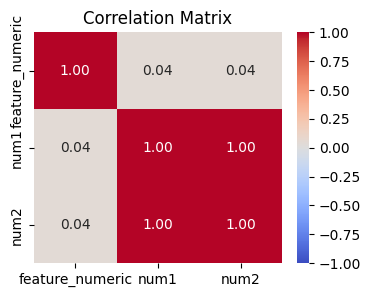

In [4]:
# --- 숫자형 컬럼 간 상관관계 Heatmap ---
numeric_cols = ['feature_numeric', 'num1', 'num2']
corr = df[numeric_cols].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

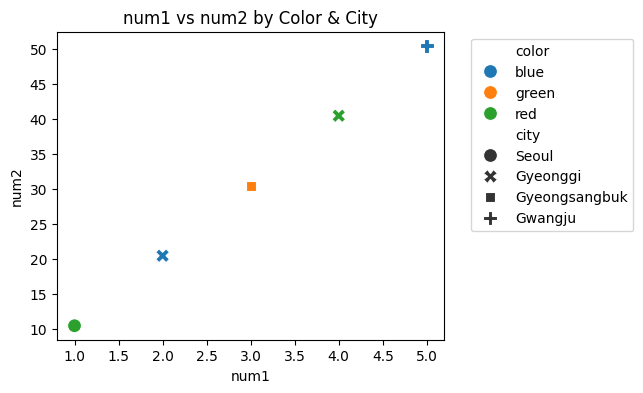

In [5]:
# --- 산점도 with hue/style ---
plt.figure(figsize=(5,4))
sns.scatterplot(
    x='num1', y='num2',
    hue='color', style='city',
    s=100, data=df
)
plt.title('num1 vs num2 by Color & City')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

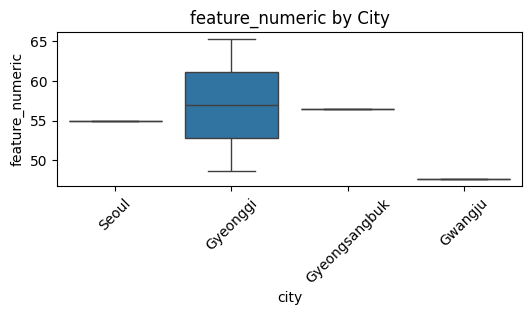

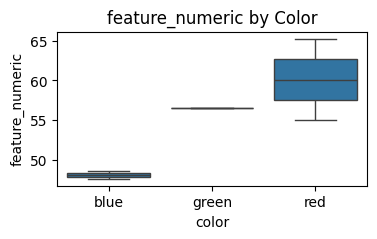

In [6]:
# --- 연속형 vs 범주형 분포 비교 (Boxplot) ---
plt.figure(figsize=(6,2))
sns.boxplot(x='city', y='feature_numeric', data=df)
plt.title('feature_numeric by City')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x='color', y='feature_numeric', data=df)
plt.title('feature_numeric by Color')
plt.show()

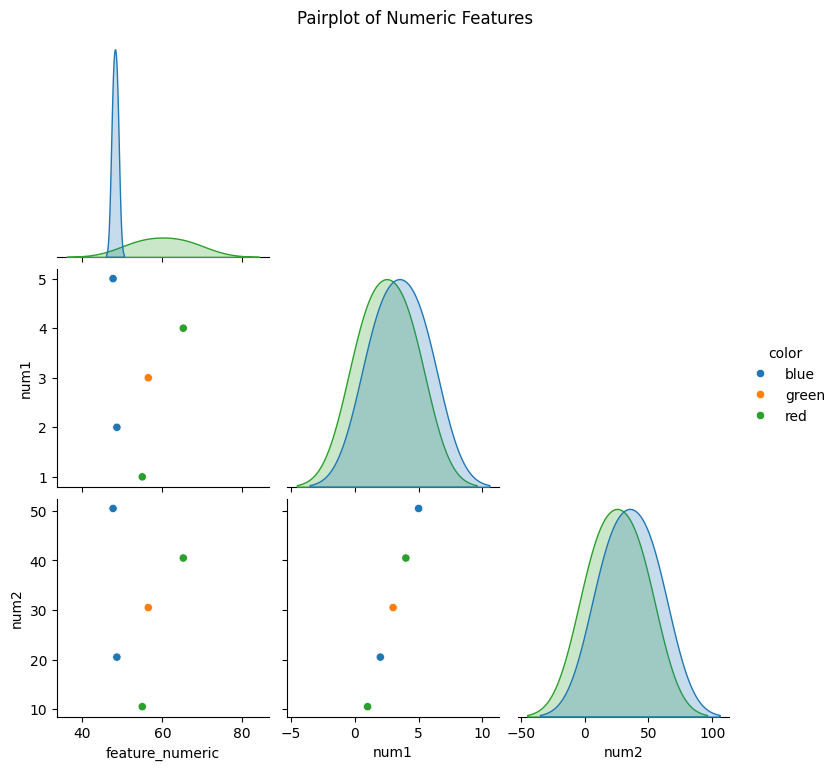

In [7]:
# --- 다변량 산점도 매트릭스 (Pairplot) ---
sns.pairplot(
    df,
    vars=numeric_cols,
    hue='color',
    diag_kind='kde',
    corner=True
)
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

# --- 7) 다중공선성(Multicollinearity) 체크 (VIF) ---